# Feature Scaling and Learining rate (Multi-Variable)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Notation  
  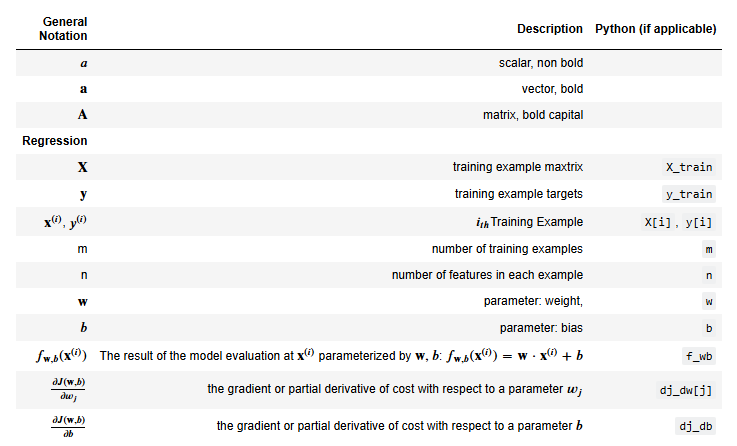

In [2]:
path = r"C:\Machine Learning\Coursera\Supervised ML (Regression and Classification)\02_Regression_Multiple_Variable\houses.txt"
with open(path) as f:
    print(f.readline())

9.520000000000000000e+02,2.000000000000000000e+00,1.000000000000000000e+00,6.500000000000000000e+01,2.715000000000000000e+02



In [3]:
data = np.loadtxt(path, delimiter=",")

X_train = data[:, :4]
y_train = data[:, 4]

X_features = ['size(sqft)','bedrooms','floors','age']

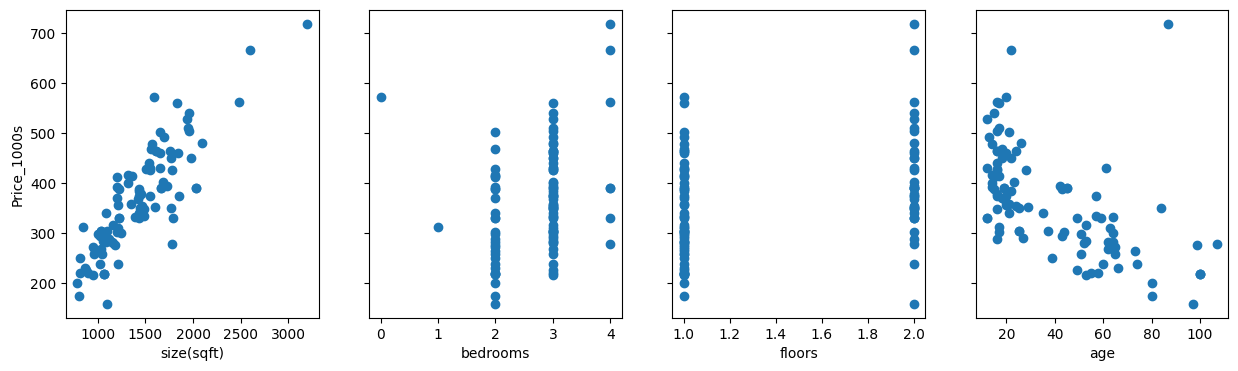

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(15,4), sharey=True)

for i in range(len(ax)):
    ax[i].scatter(X_train[:,i], y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price_1000s")
plt.show()

## z-score normalization
- After z-score normalization, all features will have a mean of 0 and a standard deviation of 1.
- To implement z-score normalization, we use this formula:  
  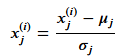  

  $\mu_j$ is the mean and $\sigma_j$ is standard deviation of feature j.  
    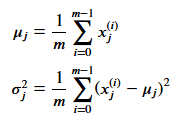  

  $(\sigma_j)^2$ or $\sigma_j^2$ is variance.

In [ ]:
def zscore_normalize_features(X):
    # find mean
    mu = np.mean(X, axis=0)
    # find standard deviation
    sigma = np.std(X, axis=0)

    X_norm = (X - mu)/sigma

    return X_norm, mu, sigma

numpy.ndarray

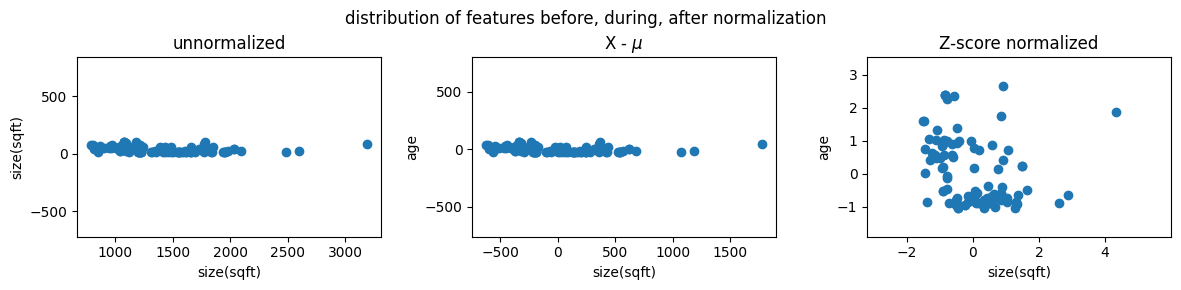

In [6]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)
X_mean = X_train - mu
X_norm = (X_train - mu)/sigma

fig, ax = plt.subplots(1, 3, figsize=(12,3))

ax[0].scatter(X_train[:,0],X_train[:,3])
ax[0].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[0])
ax[0].set_title('unnormalized')
ax[0].axis('equal') # axis('equal') makes the x-axis and y-axis use the same scale.

ax[1].scatter(X_mean[:,0], X_mean[:,3])
ax[1].set_xlabel(X_features[0])
ax[1].set_ylabel(X_features[3])
ax[1].set_title(r"X - $\mu$")
ax[1].axis('equal')

ax[2].scatter(X_norm[:,0], X_norm[:,3])
ax[2].set_xlabel(X_features[0])
ax[2].set_ylabel(X_features[3])
ax[2].set_title(r"Z-score normalized")
ax[2].axis('equal')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before, during, after normalization")
plt.show()

In [ ]:
# Normalize the original features
X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print(f"X_mu = {X_mu} \nX_sigma = {X_sigma}")
print(f"Peak to Peak range by column in Raw X: {np.ptp(X_train,axis=0)}")
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_norm,axis=0)}")
# np.ptp calculate peak to peak range(max - min)

X_mu = [1.41371e+03 2.71000e+00 1.38000e+00 3.86500e+01] 
X_sigma = [412.17283499   0.65261014   0.48538644  25.78502472]
Peak to Peak range by column in Raw X: [2.406e+03 4.000e+00 1.000e+00 9.500e+01]
Peak to Peak range by column in Normalized X: [5.83735704 6.12923357 2.06021411 3.68430905]
